This note is based on Tensorflow 2.13.1, python 3.9; The aim is to learn the architecture of this conplex module and use it to train model.

### Necessary Modules

In [1]:
import tensorflow as tf
tf.__version__

'2.13.1'

In [13]:
import sys
import sklearn
import numpy as np
import os
np.random.seed(33)
import pandas as pd

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
import os_and_file
from tensorflow import keras

# Keras for MLP Classifying

### Activation Functions

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

### Load Mnist Data

In [4]:
imported_mnist = keras.datasets.fashion_mnist
(X_tr_full,y_tr_full),(X_ts,y_ts)=imported_mnist.load_data() # dtype=='uint8',that is 255-bit

Figure is stored in 3-d array (60000,28,28).

In [5]:
X_val, X_tr = X_tr_full[:5000] / 255., X_tr_full[5000:] / 255. # Normalize to [0,1], float
y_val, y_tr = y_tr_full[:5000], y_tr_full[5000:]
X_ts = X_ts / 255.

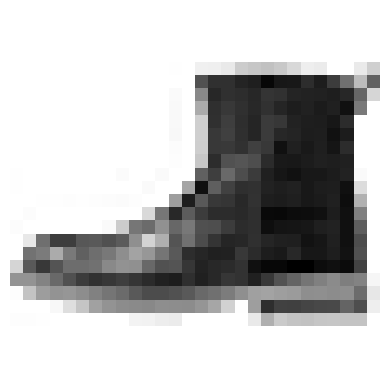

In [6]:
plt.imshow(X_tr[3],cmap='binary') # 33th in 0-axis, 28*28
plt.axis('off')
plt.show() # show the innerly built fig

In [6]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"] # Corresponding names

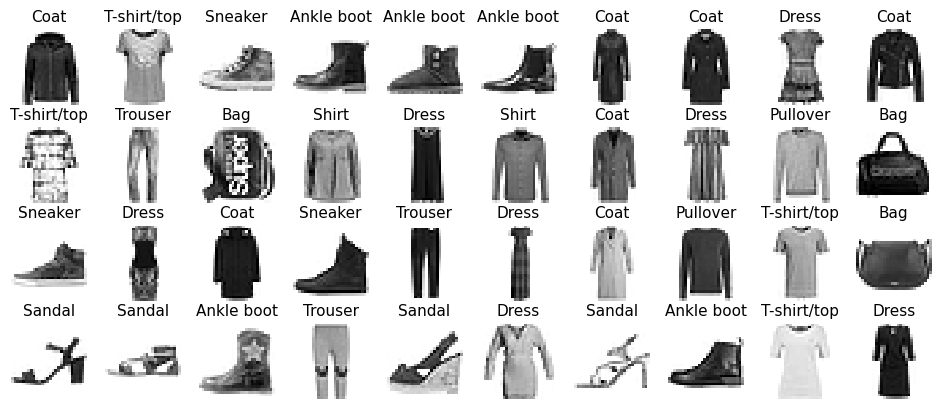

In [7]:
sp_rows = 4
sp_cols = 10
plt.figure(figsize=(sp_cols*1.2,sp_rows*1.2))
for row in range(sp_rows):
    for col in range(sp_cols):
        index=sp_cols*row+col
        plt.subplot(sp_rows,sp_cols,index+1) # 按坐标放图的位置指令
        plt.imshow(X_tr[index],cmap="binary",interpolation='nearest') # 插值方法
        plt.axis("off")
        plt.title(class_names[y_tr[index]],fontsize=11)
plt.subplots_adjust(wspace=0.1,hspace=0.3)
plt.show()

### Model Building Steps

Flatten layer make input_shape-data into a flat layer, that is a shape transformer:

In [9]:
model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))

2024-10-25 12:10:18.715113: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2024-10-25 12:10:18.715139: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2024-10-25 12:10:18.715143: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2024-10-25 12:10:18.715348: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-10-25 12:10:18.715361: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Dense layer is the fully-connected layers:

In [10]:
model.add(keras.layers.Dense(300,activation="relu"))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax")) # Make output into [0,1]
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266610 (1.02 MB)
Trainable params: 266610 (1.02 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Build Model Framework: Sequential API

Reset keras:

In [50]:
keras.backend.clear_session() # clear graphs
np.random.seed(33)
tf.random.set_seed(33)
try:
    del model
    print("Model cleared")
except:
    print("No model now")

Model cleared


We can write these into one block:

In [57]:
model=keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(200,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10,activation='softmax')
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_5 (Dense)             (None, 200)               157000    
                                                                 
 dense_6 (Dense)             (None, 50)                10050     
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_7 (Dense)             (None, 10)                510       
                                                                 
Total params: 167560 (654.53 KB)
Trainable params: 167560 (654.53 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Check the Model

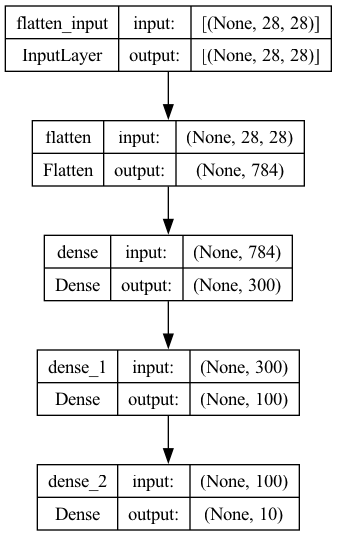

In [40]:
keras.utils.plot_model(model,to_file="./image/f_mnist_model.png",show_shapes=True)

Now let's chect the layers list, whose element is a class with name property:

In [21]:
for i in range(len(model.layers)):
    print("The "+str(i)+"th layer is: "+model.layers[i].name)

The 0th layer is: flatten
The 1th layer is: dense
The 2th layer is: dense_1
The 3th layer is: dense_2


Now we check the weights and bias of dense layers:

In [41]:
for i in range(len(model.layers)-1):
    weights,bias = model.layers[i+1].get_weights()
    print("The "+str(i+1)+"th layer have weights: "+str(weights.shape)+", bias: "+str(bias.shape))

The 1th layer have weights: (784, 300), bias: (300,)
The 2th layer have weights: (300, 100), bias: (100,)
The 3th layer have weights: (100, 10), bias: (10,)


Weights are randomized:

In [43]:
model.layers[1].get_weights()

[array([[-0.0192029 ,  0.04483777, -0.03916928, ...,  0.04375406,
          0.0237377 , -0.02449168],
        [-0.01030174,  0.06679133,  0.03110175, ...,  0.05429174,
         -0.02637557, -0.04947926],
        [ 0.01896143,  0.0255995 ,  0.06797872, ...,  0.01885983,
          0.05492473,  0.05482677],
        ...,
        [-0.05505395,  0.03352181, -0.03962305, ..., -0.04665205,
          0.00096151,  0.03286734],
        [-0.0676115 ,  0.03647875, -0.07291077, ..., -0.01255455,
         -0.03448037, -0.0244988 ],
        [-0.05626931,  0.04259416, -0.06140746, ...,  0.00041074,
         -0.01884411,  0.05501996]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

For flatten layer there is certenly no weights or bias:

In [44]:
model.layers[0].get_config()

{'name': 'flatten',
 'trainable': True,
 'dtype': 'float32',
 'batch_input_shape': (None, 28, 28),
 'data_format': 'channels_last'}

In [46]:
model.layers[2].get_config()

{'name': 'dense_1',
 'trainable': True,
 'dtype': 'float32',
 'units': 100,
 'activation': 'relu',
 'use_bias': True,
 'kernel_initializer': {'module': 'keras.initializers',
  'class_name': 'GlorotUniform',
  'config': {'seed': None},
  'registered_name': None},
 'bias_initializer': {'module': 'keras.initializers',
  'class_name': 'Zeros',
  'config': {},
  'registered_name': None},
 'kernel_regularizer': {'module': 'keras.regularizers',
  'class_name': 'L2',
  'config': {'l2': 0.009999999776482582},
  'registered_name': None},
 'bias_regularizer': None,
 'activity_regularizer': None,
 'kernel_constraint': None,
 'bias_constraint': None}

### Train the Model

Define the loss function and methods:

In [78]:
model.compile(
    loss="sparse_categorical_crossentropy", # keras.loss
    optimizer="sgd", # 随机梯度下降 keras.optimizers.SGD() class
    metrics=["accuracy"] # 度量评估 keras.metrics
)

Now train the model with 20 epochs:

In [79]:
history=model.fit(
    X_tr,y_tr,epochs=20,
    validation_data=(X_val,y_val)
)

Epoch 1/20
   1/1719 [..............................] - ETA: 7:14 - loss: 2.4616 - accuracy: 0.0312

2024-10-25 14:46:14.154076: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1715/1719 [============================>.] - ETA: 0s - loss: 0.7786 - accuracy: 0.7503

2024-10-25 14:46:20.602995: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - 7s 4ms/step - loss: 0.7780 - accuracy: 0.7505 - val_loss: 0.5902 - val_accuracy: 0.8006
Epoch 2/20
1719/1719 [==============================] - 6s 4ms/step - loss: 0.5466 - accuracy: 0.8154 - val_loss: 0.5130 - val_accuracy: 0.8332
Epoch 3/20
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4970 - accuracy: 0.8303 - val_loss: 0.4801 - val_accuracy: 0.8360
Epoch 4/20
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4724 - accuracy: 0.8369 - val_loss: 0.4538 - val_accuracy: 0.8478
Epoch 5/20
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4573 - accuracy: 0.8422 - val_loss: 0.4558 - val_accuracy: 0.8440
Epoch 6/20
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4465 - accuracy: 0.8461 - val_loss: 0.4433 - val_accuracy: 0.8482
Epoch 7/20
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4390 - accuracy: 0.8470 - val_loss: 0.4319 - val_accuracy: 0.8528
Epo

Visualize:

<function matplotlib.pyplot.show(close=None, block=None)>

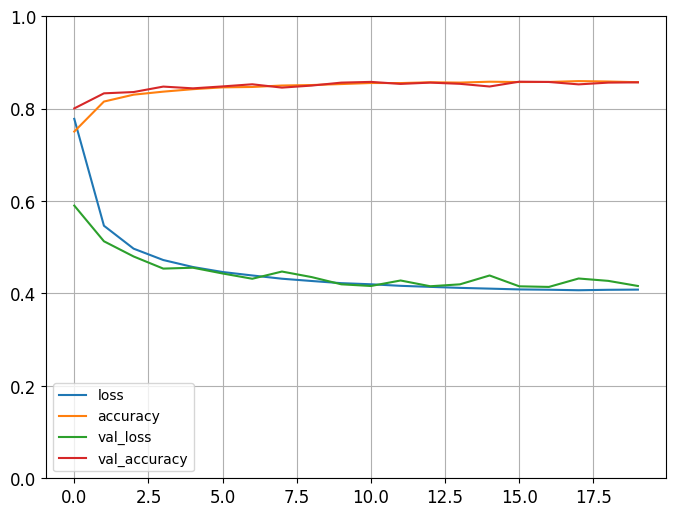

In [80]:
pd.DataFrame(history.history).plot(figsize=(8,6))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

### Validate the Model

In [61]:
model.evaluate(X_ts,y_ts)

313/313 [==============================] - 1s 3ms/step - loss: 0.4729 - accuracy: 0.8315


[0.47289586067199707, 0.8314999938011169]

In [65]:
X_new=X_ts[:3] # first 3 picture
y_proba=model.predict(X_new)
y_proba.round(2) # 四舍五入

1/1 [==============================] - 0s 169ms/step


2024-10-25 13:50:30.823304: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.09, 0.  , 0.15, 0.  , 0.76],
       [0.  , 0.  , 0.94, 0.  , 0.03, 0.  , 0.03, 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

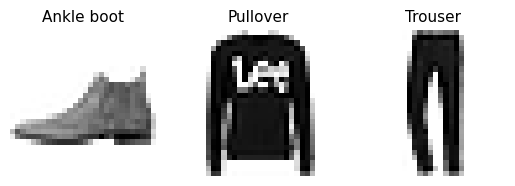

In [67]:
y_pred=np.argmax(y_proba,axis=-1)
for index in range(3):
    plt.subplot(1,3,index+1) # 按坐标放图的位置指令
    plt.imshow(X_ts[index],cmap="binary",interpolation='nearest') # 插值方法
    plt.axis("off")
    plt.title(class_names[y_pred[index]],fontsize=11)

# Other APIs

### More Connections

Here we want a conection directly from Flat to Output:

In [81]:
keras.backend.clear_session() # clear graphs
np.random.seed(33)
tf.random.set_seed(33)
try:
    del model
    print("Model cleared")
except:
    print("No model now")

Model cleared


In [ ]:
input_ = keras.layers.Input(shape=[28, 28])
flatten=keras.layers.Flatten()(input_) # defined by connecting parameter
hidden1=keras.layers.Dense(300,activation="relu")(flatten)
hidden2=keras.layers.Dense(50,activation="relu")(hidden1)
concat=keras.layers.concatenate([flatten,hidden2]) # put together
output=keras.layers.Dense(10,activation="softmax")(concat)

In [ ]:
model=keras.models.Model(inputs=[input_],outputs=[output])
model.summary()

### More Inputs Flow

This enables mutiple inputs:

In [85]:
keras.backend.clear_session() # clear graphs
np.random.seed(33)
tf.random.set_seed(33)
try:
    del model
    print("Model cleared")
except:
    print("No model now")

Model cleared


In [86]:
input_A = keras.layers.Input(shape=[28, 28],name="deep_op") # deep
input_B = keras.layers.Input(shape=[28, 28],name="wide_op") # wide
flatten_A=keras.layers.Flatten()(input_A) 
flatten_B=keras.layers.Flatten()(input_B)
hidden1=keras.layers.Dense(300,activation="relu")(flatten_A)
hidden2=keras.layers.Dense(50,activation="relu")(hidden1)
concat=keras.layers.concatenate([flatten_B,hidden2])
output=keras.layers.Dense(10,name='output',activation="softmax")(concat)
model = keras.models.Model(inputs=[input_A, input_B], outputs=[output])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 deep_op (InputLayer)        [(None, 28, 28)]             0         []                            
                                                                                                  
 flatten (Flatten)           (None, 784)                  0         ['deep_op[0][0]']             
                                                                                                  
 wide_op (InputLayer)        [(None, 28, 28)]             0         []                            
                                                                                                  
 dense (Dense)               (None, 300)                  235500    ['flatten[0][0]']             
                                                                                              

### More Output

Multiple outputs, training will base on all of them:

In [21]:
keras.backend.clear_session() # clear graphs
np.random.seed(33)
tf.random.set_seed(33)
try:
    del model
    print("Model cleared")
except:
    print("No model now")

No model now


In [23]:
input_= keras.layers.Input(shape=[28, 28])
flatten=keras.layers.Flatten()(input_) 
hidden1=keras.layers.Dense(300,activation="relu")(flatten)
hidden2=keras.layers.Dense(50,activation="relu")(hidden1)

concat=keras.layers.concatenate([flatten,hidden2])
output=keras.layers.Dense(10,name='output',activation="softmax")(concat)

aux_output=keras.layers.Dense(10,name='aux_output',activation="softmax")(hidden2)

model = keras.models.Model(inputs=[input_], outputs=[output,aux_output])
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 28, 28)]             0         []                            
                                                                                                  
 flatten_1 (Flatten)         (None, 784)                  0         ['input_2[0][0]']             
                                                                                                  
 dense_2 (Dense)             (None, 300)                  235500    ['flatten_1[0][0]']           
                                                                                                  
 dense_3 (Dense)             (None, 50)                   15050     ['dense_2[0][0]']             
                                                                                            

In [24]:
model.compile(
    loss=["sparse_categorical_crossentropy","sparse_categorical_crossentropy"], # Note we have 2 terms here
    optimizer=keras.optimizers.SGD(),
    loss_weights=[0.9,0.1],
    metrics=["accuracy"] 
    )

In [25]:
history=model.fit(
    X_tr,y_tr,epochs=20,
    validation_data=(X_val,y_val)
)

Epoch 1/20
   1/1719 [..............................] - ETA: 8:41 - loss: 2.3442 - output_loss: 2.2992 - aux_output_loss: 2.7495 - output_accuracy: 0.1875 - aux_output_accuracy: 0.1250

2024-10-25 22:14:42.135095: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - ETA: 0s - loss: 0.8571 - output_loss: 0.7997 - aux_output_loss: 1.3736 - output_accuracy: 0.7410 - aux_output_accuracy: 0.5395

2024-10-25 22:14:52.299061: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - 11s 6ms/step - loss: 0.8571 - output_loss: 0.7997 - aux_output_loss: 1.3736 - output_accuracy: 0.7410 - aux_output_accuracy: 0.5395 - val_loss: 0.6331 - val_output_loss: 0.6081 - val_aux_output_loss: 0.8582 - val_output_accuracy: 0.7934 - val_aux_output_accuracy: 0.7284
Epoch 2/20
1719/1719 [==============================] - 10s 6ms/step - loss: 0.5765 - output_loss: 0.5569 - aux_output_loss: 0.7528 - output_accuracy: 0.8104 - aux_output_accuracy: 0.7557 - val_loss: 0.5354 - val_output_loss: 0.5212 - val_aux_output_loss: 0.6632 - val_output_accuracy: 0.8282 - val_aux_output_accuracy: 0.7924
Epoch 3/20
1719/1719 [==============================] - 11s 7ms/step - loss: 0.5181 - output_loss: 0.5056 - aux_output_loss: 0.6306 - output_accuracy: 0.8245 - aux_output_accuracy: 0.7941 - val_loss: 0.4973 - val_output_loss: 0.4874 - val_aux_output_loss: 0.5866 - val_output_accuracy: 0.8336 - val_aux_output_accuracy: 0.8054
Epoch 4/20
1719/1719 [========

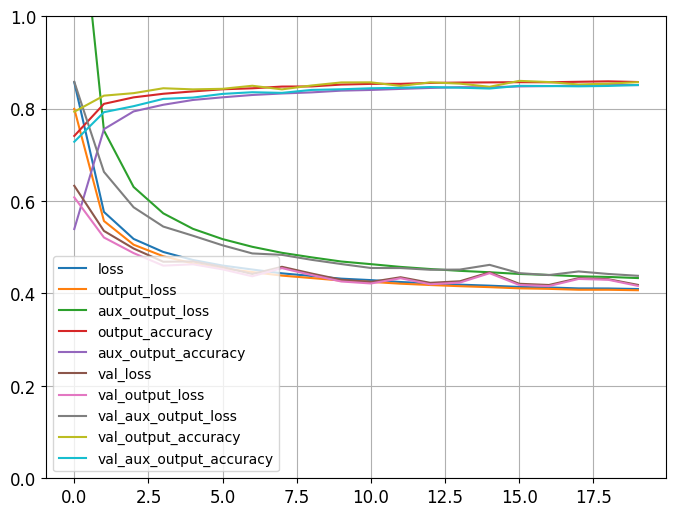

In [26]:
pd.DataFrame(history.history).plot(figsize=(8,6))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

### Subclassing API

Dynamic control of the model is possible in this method!